In [262]:
import random
import numpy as np

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [263]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]
pandas: 2.2.3
numpy: 2.1.1
scikit-learn: 1.8.0


In [264]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")


In [265]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 20)
X_test : (1409, 20)
y_train: (5634,)
y_test : (1409,)


# T020 Dummy Class

In [266]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

In [267]:
dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [268]:
y_pred_dummy = dummy_model.predict(X_test)

In [269]:
pd.Series(y_pred_dummy).value_counts()

0    1409
Name: count, dtype: int64

1.409 khách hàng → Dummy nói tất cả đều không churn.

In [270]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_precision = precision_score(y_test, y_pred_dummy, zero_division=0)
dummy_recall = recall_score(y_test, y_pred_dummy, zero_division=0)
dummy_f1 = f1_score(y_test, y_pred_dummy,zero_division=0)

print(f"Accuracy score: {dummy_accuracy:.4f}")
print(f"Precision score: {dummy_precision:.4f}")
print(f"Recal score: {dummy_recall:.4f}")
print(f"F1 score: {dummy_f1:.4f}")

cm_dummy = confusion_matrix(
    y_test,
    y_pred_dummy
)

print(cm_dummy)


Accuracy score: 0.7346
Precision score: 0.0000
Recal score: 0.0000
F1 score: 0.0000
[[1035    0]
 [ 374    0]]


TN ≈ 1035
Không churn → đoán không churn ✅

FP = 0
Không churn → đoán churn

FN ≈ 374
CHURN → nhưng đoán không churn ❌

TP = 0
CHURN → đoán đúng churn

### T020 — Baseline Findings

The DummyClassifier using the `most_frequent` strategy achieved:

- Accuracy: 73.46%
- Precision: 0.00%
- Recall: 0.00%
- F1-score: 0.00%

The confusion matrix was:

[[1035, 0],
 [374, 0]]

Although the baseline achieved 73.46% accuracy, it predicted every customer
as non-churn and failed to identify all 374 churn customers.

Therefore, accuracy alone is misleading due to class imbalance. Subsequent
models must be compared against this baseline, particularly using metrics
such as Precision, Recall and F1-score for the churn class.

# T021 Logistic Regression

In [271]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))
print("Total:", len(numerical_features) + len(categorical_features))

Numerical: 4
Categorical: 16
Total: 20


In [272]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
  transformers=[
    (
      "num",
      StandardScaler(),
      numerical_features
    ),
    (
      "cat",
      OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary"
      ),
      categorical_features
    )
  ]
)

In [273]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
  max_iter=1000,
  random_state=42
)

In [274]:
from sklearn.pipeline import Pipeline
lr_pipeline = Pipeline(
  steps=[
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
  ]
)

In [275]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [276]:
y_pred_lr = lr_pipeline.predict(X_test)

In [277]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

Accuracy : 0.8027
Precision: 0.6446
Recall   : 0.5722
F1-score : 0.6062
[[917 118]
 [160 214]]


917 TN người không churn -> predict đúng
214 TP người churn -> predict đúng 
118 FP người thực tế không churn -> predict sai (model lại báo churn)
160 FN người thực tế churn -> predict sai (model lại báo không churn) ** đặc biệt quan tâm 

Precision = (TP) / (TP + FP ) = 64,46%. model cảnh báo cứ 100 khách hàng có nguy cơ churn khoảng 64 người thực sự churn --> những người tôi cảnh báo có chính xác không ? 
Recall = TP / (TP + FN) = 57,22%. có 100 khách hàng thật sự churn -> phát hiện 57, bỏ sót 43                            --> tôi bắt được bao nhiêu người churn

# T021 Decision Tree


In [278]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [279]:
tree_preprocessor = ColumnTransformer(
  transformers=[
    (
      "cat",
      OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary"
      ),
      categorical_features
    )
  ],
  remainder="passthrough" # nghia la nhung cot con lai cu giu nguyen
)

In [280]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
  random_state=42
)

In [281]:
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(
  steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", decision_tree)
  ]
)

In [282]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [283]:
y_pred_dt = dt_pipeline.predict(X_test)

In [284]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print(cm_dt)

Accuracy : 0.7268
Precision: 0.4857
Recall   : 0.5000
F1-score : 0.4928
[[837 198]
 [187 187]]


[TN,FP
FN,TP]

837 no churn -> model predict dung
187 churn -> model predic dung
198 no churn -> model báo churn -> sai
187 churn -> model báo k churn -> sai 

trong 100 khach, model dung 73 nguoi -> accuracy
trong 100 khach la churn, 49 nguoi that su churn -> precision
trong 100 khach la churn, bat duoc 50 churn



In [285]:
y_pred_dt_train = dt_pipeline.predict(X_train)

dt_train_accuracy = accuracy_score(
    y_train,
    y_pred_dt_train
)

print(
    f"Train Accuracy: {dt_train_accuracy:.4f}"
)

print(
    f"Test Accuracy : {dt_accuracy:.4f}"
)

Train Accuracy: 1.0000
Test Accuracy : 0.7268


Overfitting roi

# T022 — Random Forest

In [286]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
  random_state=42
)

In [287]:
random_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [288]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
  steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", random_forest)
  ]
)

In [289]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [290]:
y_pred_rf = rf_pipeline.predict(X_test)

In [291]:
rf_accuracy = accuracy_score(
    y_test, y_pred_rf
)

rf_precision = precision_score(
    y_test, y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test, y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test, y_pred_rf,
    zero_division=0
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

Accuracy : 0.7999
Precision: 0.6513
Recall   : 0.5294
F1-score : 0.5841
[[929 106]
 [176 198]]


[TN, FN
FP, TP]
900 khong churn du doan dung
198 churn du doan dung

106 khong churn -> du doan thanh churn
176 churn -> du doan thanh khong churn 

du doan dung 80/100 
65/100 nguoi churn thuc su trong 100 nguoi 
trong 100 churn bat duoc 53 churn 

In [292]:
rf_train_accuracy = rf_pipeline.score(
    X_train,
    y_train
)

rf_test_accuracy = rf_pipeline.score(
    X_test,
    y_test
)

print(
    f"Train Accuracy: {rf_train_accuracy:.4f}"
)

print(
    f"Test Accuracy : {rf_test_accuracy:.4f}"
)

Train Accuracy: 1.0000
Test Accuracy : 0.7999


In [293]:
lr_train_accuracy = lr_pipeline.score(X_train, y_train)
lr_test_accuracy = lr_pipeline.score(X_test, y_test)

print(f"LR Train Accuracy: {lr_train_accuracy:.4f}")
print(f"LR Test Accuracy : {lr_test_accuracy:.4f}")

LR Train Accuracy: 0.8142
LR Test Accuracy : 0.8027


### T023 — Model Comparison

Three baseline classification models were compared: Logistic Regression,
Decision Tree, and Random Forest.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.27% | 64.46% | 57.22% | 60.62% |
| Decision Tree | 72.68% | 48.57% | 50.00% | 49.28% |
| Random Forest | 79.99% | 65.13% | 52.94% | 58.41% |

Logistic Regression achieved the highest Accuracy, Recall, and F1-score,
while Random Forest achieved the highest Precision.

The unrestricted Decision Tree showed strong overfitting, with 100%
training accuracy but only 72.68% test accuracy. Random Forest also
achieved 100% training accuracy while its test accuracy was 79.99%,
indicating a substantial train-test gap.

Based on the current baseline results, Logistic Regression provides the
best overall balance, particularly for identifying churn customers.
However, model selection should not be finalized until further validation
and hyperparameter tuning are performed.

### Overfitting Comparison

The train-test performance comparison shows clear differences among the
three baseline models:

| Model | Train Accuracy | Test Accuracy | Gap |
|---|---:|---:|---:|
| Logistic Regression | 81.42% | 80.27% | 1.15% |
| Decision Tree | 100.00% | 72.68% | 27.32% |
| Random Forest | 100.00% | 79.99% | 20.01% |

Logistic Regression shows the smallest train-test gap, suggesting better
generalization on the current split.

In contrast, the unrestricted Decision Tree shows strong overfitting.
Random Forest improves test performance substantially compared with the
single Decision Tree, but still shows a considerable train-test gap.

Considering predictive performance, churn recall, F1-score, model
complexity, and the observed train-test gap, Logistic Regression is the
strongest baseline candidate among the three models.

However, final model selection will be performed after hyperparameter
tuning and further validation.

# T024 

In [294]:
scoring = "f1"

In [295]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

Tạo GridSearchCV

In [296]:
from sklearn.model_selection import GridSearchCV

grid_search_rf = GridSearchCV(
  estimator=rf_pipeline,
  param_grid=param_grid,
  scoring=scoring,
  cv=5,
  n_jobs=1,
  verbose=1
)

estimator: model/ pipeline can traning
param_grid: nhung configuration can thu
scoring f1: tieu chi chon winner
cv=5: 5-fold cross validation
n_jobs: dung cac cpu kha dung

In [297]:
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [298]:
print("Best parameters:")
print(grid_search_rf.best_params_)

print(
    "Best CV F1:",
    round(grid_search_rf.best_score_, 4)
)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1: 0.5989


In [299]:
best_rf = grid_search_rf.best_estimator_

In [300]:
y_pred_rf_tuned = best_rf.predict(X_test)

In [301]:
tuned_accuracy = accuracy_score(
    y_test, y_pred_rf_tuned
)

tuned_precision = precision_score(
    y_test, y_pred_rf_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test, y_pred_rf_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test, y_pred_rf_tuned,
    zero_division=0
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-score : {tuned_f1:.4f}")

Accuracy : 0.8062
Precision: 0.6613
Recall   : 0.5535
F1-score : 0.6026


In [302]:
print(
    confusion_matrix(
        y_test,
        y_pred_rf_tuned
    )
)

[[929 106]
 [167 207]]


In [303]:
tuned_train_accuracy = best_rf.score(X_train, y_train)
tuned_test_accuracy = best_rf.score(X_test, y_test)

print(f"train: {tuned_train_accuracy}")
print(f"test: {tuned_test_accuracy}")

train: 0.8663471778487752
test: 0.8062455642299503


Decision Tree

In [304]:
dt_param_grid = {
  "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10]
}

grid_search_dt = GridSearchCV(
  estimator=dt_pipeline,
  param_grid=dt_param_grid,
  scoring=scoring,
  cv=5,
  n_jobs=1
)

grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)

print(f"Train: {best_dt.score(X_train, y_train)}")
print(f"Test: {best_dt.score(X_test, y_test)}")

Train: 0.8264110756123536
Test: 0.7920511000709723


# T025

In [305]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, model_name):
  ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Greens"
  )

  plt.title(f"Confusion Matrix - {model_name}")

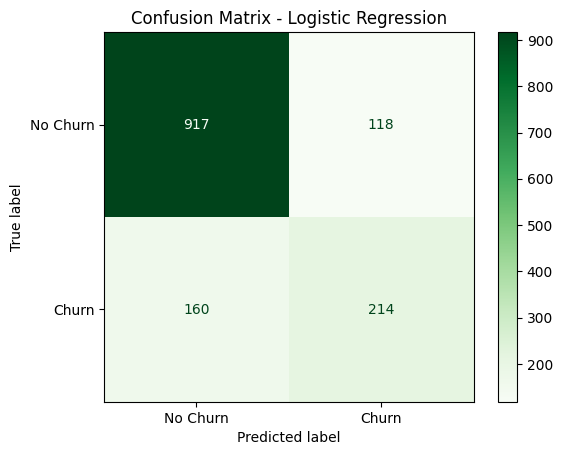

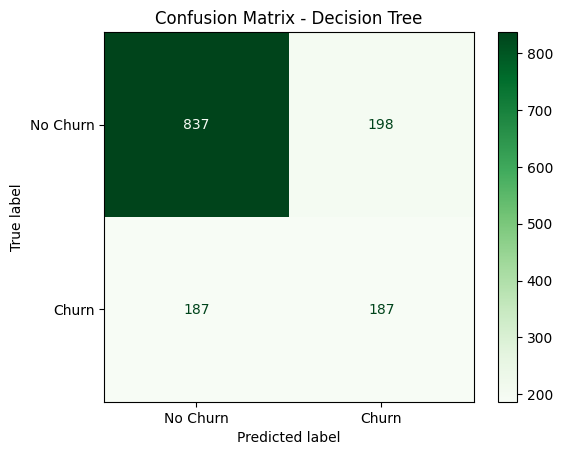

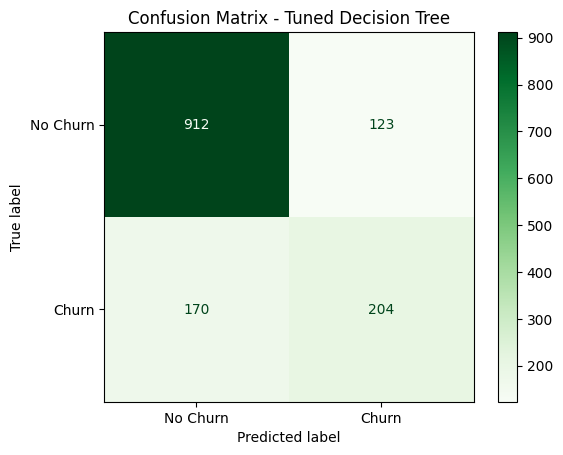

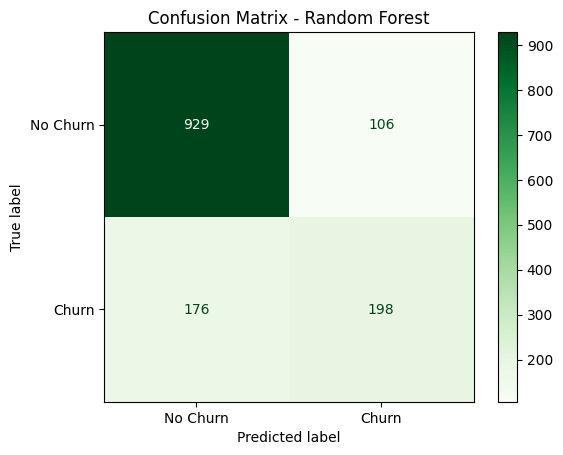

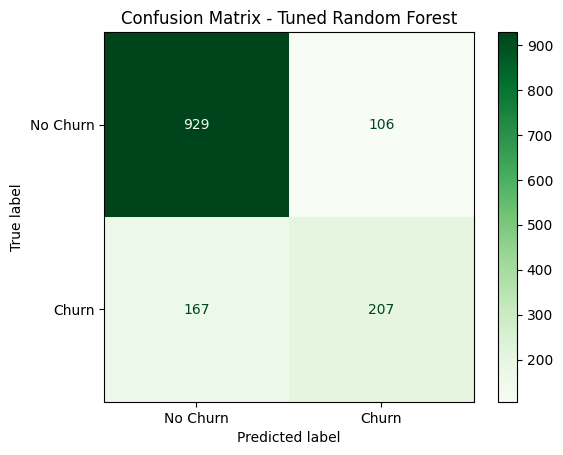

In [306]:
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
plot_confusion_matrix(y_test, y_pred_dt_tuned, "Tuned Decision Tree")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_rf_tuned, "Tuned Random Forest")


In [307]:
import pandas as pd
from sklearn.metrics import confusion_matrix

models_pred = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Tuned Decision Tree": y_pred_dt_tuned,
    "Random Forest": y_pred_rf,
    "Tuned Random Forest": y_pred_rf_tuned
}

rows = []

for model_name, y_pred in models_pred.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    rows.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

cm_table = pd.DataFrame(rows)

cm_table

,Model,TN,FP,FN,TP
0,Logistic Regression,917,118,160,214
1,Decision Tree,837,198,187,187
2,Tuned Decision Tree,912,123,170,204
3,Random Forest,929,106,176,198
4,Tuned Random Forest,929,106,167,207


### Phân tích confusion matrix
- ** Losgistic Regression số lượng FN thấp nhât 160 và TP cao nhất 170, cho thấy phát hiện được nhiều khách hàng thực sự Churn nhất và bỏ sót ít khách hàng Churn nhất trong các model
- ** Decision Tree trước khi tuning có kết quả kém nhất 
- ** Sau khi tuning, Decision Trê có cải thiện, 
- ** Random forest, ít canhr báo khách hàng churn hơn LR, tuy nhiên bỏ sót nhiều khách hàng thực sự churn 
- ** Sau khi tuning, 

### Kết luận

Các mô hình thể hiện sự đánh đổi giữa khả năng phát hiện khách hàng churn và khả năng hạn chế cảnh báo nhầm.

- Nếu ưu tiên **phát hiện càng nhiều khách hàng churn càng tốt**, Logistic Regression hiện có lợi thế vì có FN thấp nhất và TP cao nhất.
- Nếu ưu tiên **giảm số lượng cảnh báo churn sai**, Tuned Random Forest có lợi thế vì có FP thấp nhất.

Do đó, chưa thể lựa chọn mô hình tốt nhất chỉ dựa trên Confusion Matrix. Cần tiếp tục đánh giá Precision, Recall và F1-score ở bước tiếp theo.

# T026


In [308]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

models_pred = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Tuned Decision Tree": y_pred_dt_tuned,
    "Random Forest": y_pred_rf,
    "Tuned Random Forest": y_pred_rf_tuned
}

results = []

for model_name, y_pred in models_pred.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_table = pd.DataFrame(results)

metrics_table

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.802697,0.644578,0.572193,0.606232
1,Decision Tree,0.726757,0.485714,0.500000,0.492754
2,Tuned Decision Tree,0.792051,0.623853,0.545455,0.582026
3,Random Forest,0.799858,0.651316,0.529412,0.584071
4,Tuned Random Forest,0.806246,0.661342,0.553476,0.602620


Accuracy
→ Tổng thể đoán đúng bao nhiêu?

Precision
→ Tôi CẢNH BÁO churn → đáng tin bao nhiêu?

Recall
→ Khách THỰC SỰ churn → tôi bắt được bao nhiêu?

F1
→ Precision và Recall → cân bằng tốt không?

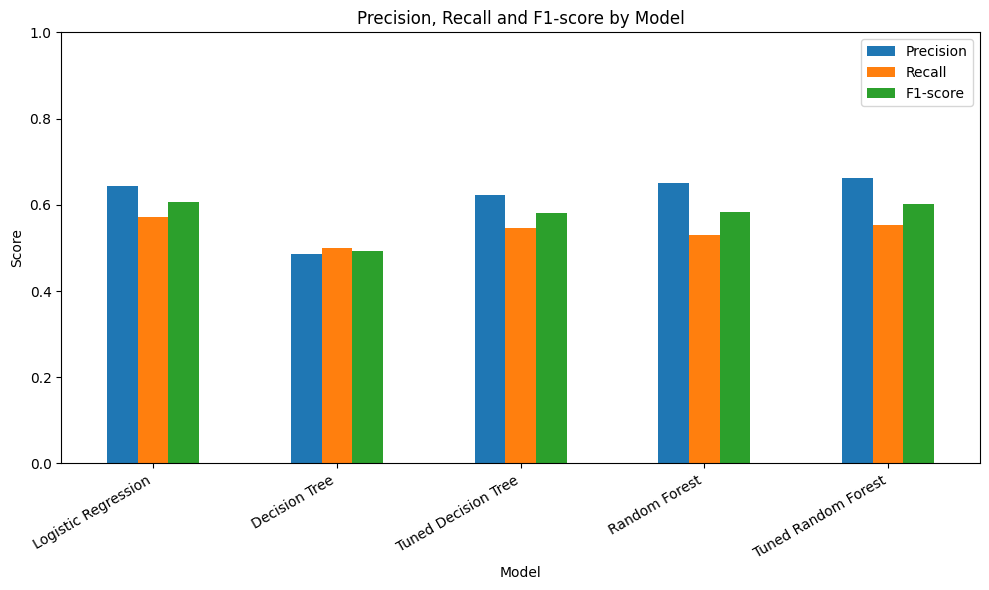

In [309]:
metrics_plot = metrics_table.set_index("Model")[
    ["Precision", "Recall", "F1-score"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Precision, Recall and F1-score by Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


### T026 — Phân tích Precision, Recall và F1-score

Do dữ liệu Customer Churn có sự mất cân bằng giữa hai lớp, Accuracy không
được sử dụng như tiêu chí duy nhất để đánh giá mô hình. Precision, Recall
và F1-score được sử dụng để đánh giá cụ thể hơn khả năng dự đoán lớp Churn.

Kết quả cho thấy:

- **Tuned Random Forest** đạt Accuracy cao nhất (80.62%) và Precision cao
  nhất (66.13%). Điều này cho thấy mô hình có tỷ lệ dự đoán đúng tổng thể
  cao nhất và các cảnh báo churn có độ chính xác cao nhất.

- **Logistic Regression** đạt Recall cao nhất (57.22%), nghĩa là mô hình
  phát hiện được tỷ lệ khách hàng thực sự churn cao nhất. Kết quả này phù
  hợp với Confusion Matrix khi Logistic Regression có số False Negative
  thấp nhất (FN = 160).

- Logistic Regression cũng đạt F1-score cao nhất (60.62%), cho thấy sự cân
  bằng tốt nhất giữa Precision và Recall trong các mô hình được đánh giá.
  Tuy nhiên, Tuned Random Forest có F1-score rất gần (60.26%).

- Hyperparameter tuning cải thiện cả Decision Tree và Random Forest trên
  Accuracy, Precision, Recall và F1-score so với các phiên bản baseline.

### Kết luận

Không có một mô hình duy nhất tốt nhất trên tất cả các metric.

Logistic Regression hiện có lợi thế về Recall và F1-score, phù hợp hơn khi
ưu tiên phát hiện và hạn chế bỏ sót khách hàng churn.

Tuned Random Forest có lợi thế về Accuracy và Precision, phù hợp hơn khi
ưu tiên độ chính xác của các cảnh báo churn và hạn chế cảnh báo sai.

Do đó, chưa lựa chọn mô hình cuối cùng tại bước này. Các mô hình sẽ tiếp tục
được đánh giá bằng ROC-AUC và Cross-validation trước khi lựa chọn mô hình
tốt nhất.

# T027

In [310]:
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [311]:
from sklearn.metrics import roc_auc_score

auc_results = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_lr),
    "Decision Tree": roc_auc_score(y_test, y_prob_dt),
    "Tuned Decision Tree": roc_auc_score(y_test, y_prob_dt_tuned),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "Tuned Random Forest": roc_auc_score(y_test, y_prob_rf_tuned)
}

for model, auc in auc_results.items():
    print(f"{model}: {auc:.4f}")

Logistic Regression: 0.8489
Decision Tree: 0.6543
Tuned Decision Tree: 0.8272
Random Forest: 0.8371
Tuned Random Forest: 0.8494


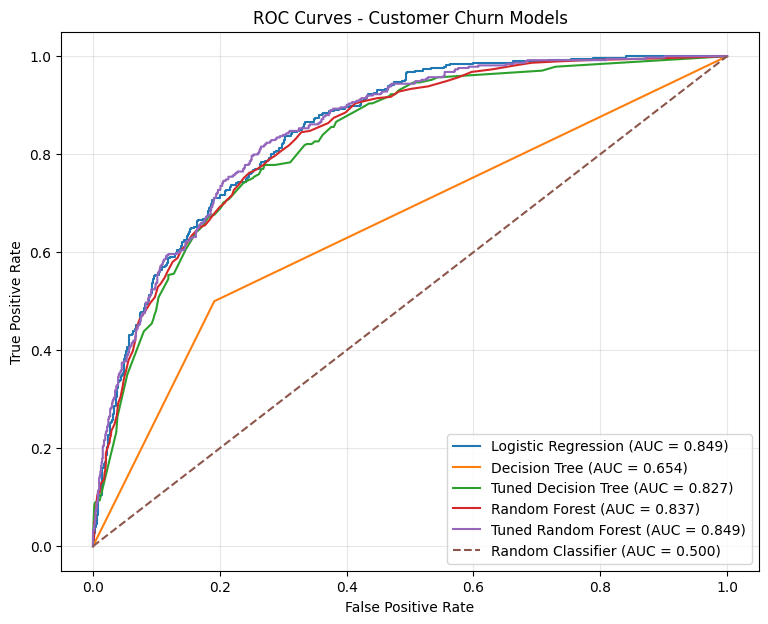

In [312]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

models_prob = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Tuned Decision Tree": y_prob_dt_tuned,
    "Random Forest": y_prob_rf,
    "Tuned Random Forest": y_prob_rf_tuned
}

plt.figure(figsize=(9, 7))

for model_name, y_prob in models_prob.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Customer Churn Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [313]:
auc_table = pd.DataFrame({
    "Model": list(auc_results.keys()),
    "ROC-AUC": list(auc_results.values())
})

auc_table = auc_table.sort_values(
    "ROC-AUC",
    ascending=False
)

auc_table

,Model,ROC-AUC
4,Tuned Random Forest,0.849411
0,Logistic Regression,0.848903
3,Random Forest,0.837071
2,Tuned Decision Tree,0.827182
1,Decision Tree,0.654348


### T027 — Đánh giá ROC-AUC

ROC-AUC được sử dụng để đánh giá khả năng phân biệt giữa khách hàng Churn
và No Churn của các mô hình trên nhiều ngưỡng phân loại khác nhau.

ROC Curve biểu diễn mối quan hệ giữa True Positive Rate (TPR) và False
Positive Rate (FPR). Trong đó, TPR tương ứng với Recall của lớp Churn,
còn FPR phản ánh tỷ lệ khách hàng không churn bị dự đoán nhầm thành churn.

AUC (Area Under the ROC Curve) tóm tắt khả năng phân biệt của mô hình thành
một giá trị duy nhất. Giá trị AUC càng cao cho thấy mô hình có khả năng
phân biệt hai lớp tốt hơn.

In [314]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

models_pred = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Tuned Decision Tree": y_pred_dt_tuned,
    "Random Forest": y_pred_rf,
    "Tuned Random Forest": y_pred_rf_tuned
}

results = []

for model_name, y_pred in models_pred.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_table = pd.DataFrame(results)

metrics_table

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.802697,0.644578,0.572193,0.606232
1,Decision Tree,0.726757,0.485714,0.500000,0.492754
2,Tuned Decision Tree,0.792051,0.623853,0.545455,0.582026
3,Random Forest,0.799858,0.651316,0.529412,0.584071
4,Tuned Random Forest,0.806246,0.661342,0.553476,0.602620


### T027 — Phân tích ROC-AUC

ROC-AUC được sử dụng để đánh giá khả năng phân biệt giữa khách hàng Churn
và No Churn của các mô hình trên nhiều ngưỡng phân loại khác nhau.

Kết quả cho thấy:

- **Tuned Random Forest** đạt ROC-AUC cao nhất với 0.8494.
- **Logistic Regression** đạt ROC-AUC 0.8489, gần như tương đương với
  Tuned Random Forest.
- Random Forest baseline đạt ROC-AUC 0.8371.
- Tuned Decision Tree đạt ROC-AUC 0.8272.
- Decision Tree baseline có ROC-AUC thấp nhất với 0.6543.

Hyperparameter tuning cải thiện khả năng phân biệt của cả Decision Tree
và Random Forest. Đặc biệt, ROC-AUC của Decision Tree tăng từ 0.6543 lên
0.8272 sau tuning, cho thấy việc kiểm soát độ phức tạp của cây giúp cải
thiện đáng kể khả năng tổng quát hóa.

Tuned Random Forest đạt ROC-AUC cao nhất, tuy nhiên mức chênh lệch so với
Logistic Regression rất nhỏ (khoảng 0.0005). Vì vậy, chưa thể kết luận
Tuned Random Forest vượt trội hơn Logistic Regression chỉ dựa trên ROC-AUC.

Kết hợp với các kết quả trước đó, Logistic Regression và Tuned Random
Forest hiện là hai ứng viên mạnh nhất. Cần tiếp tục đánh giá độ ổn định
bằng Cross-validation trước khi lựa chọn mô hình cuối cùng.

# T028

In [315]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [316]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("LR CV scores:", lr_cv_scores)
print("LR Mean AUC:", lr_cv_scores.mean())
print("LR Std:", lr_cv_scores.std())

LR CV scores: [0.86268237 0.83813194 0.85184108 0.87282488 0.86863507]
LR Mean AUC: 0.8588230671371045
LR Std: 0.012522709534693978


In [317]:
rf_cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Tuned RF CV scores:", rf_cv_scores)
print("Tuned RF Mean AUC:", rf_cv_scores.mean())
print("Tuned RF Std:", rf_cv_scores.std())

Tuned RF CV scores: [0.8538203  0.84462702 0.85778683 0.86434249 0.8709483 ]
Tuned RF Mean AUC: 0.8583049888864057
Tuned RF Std: 0.008986352903741572


In [318]:
cv_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Random Forest"
    ],
    "Mean ROC-AUC": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Std ROC-AUC": [
        lr_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_table

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.858823,0.012523
1,Tuned Random Forest,0.858305,0.008986


### T028 — Kết quả Cross-validation

5-fold Stratified Cross-validation được thực hiện trên tập training nhằm
đánh giá hiệu năng và độ ổn định của hai mô hình ứng viên chính:
Logistic Regression và Tuned Random Forest.

Kết quả cho thấy:

- **Logistic Regression** đạt Mean ROC-AUC = 0.8588 với
  Standard Deviation = 0.0125.
- **Tuned Random Forest** đạt Mean ROC-AUC = 0.8583 với
  Standard Deviation = 0.0090.

Mean ROC-AUC của hai mô hình gần như tương đương, với mức chênh lệch chỉ
khoảng 0.0005. Logistic Regression có Mean ROC-AUC nhỉnh hơn một chút,
trong khi Tuned Random Forest có Standard Deviation thấp hơn.

Standard Deviation thấp hơn cho thấy hiệu năng của Tuned Random Forest
dao động ít hơn giữa các folds và có độ ổn định cao hơn một chút trên
các tập dữ liệu validation khác nhau.

Kết quả Cross-validation nhìn chung phù hợp với kết quả ROC-AUC trên tập
test, khi cả Logistic Regression và Tuned Random Forest đều thể hiện khả
năng phân biệt Churn và No Churn tốt và có hiệu năng rất gần nhau.

### Kết luận

Không có sự khác biệt đáng kể về Mean ROC-AUC giữa hai mô hình.
Logistic Regression có hiệu năng trung bình nhỉnh hơn rất nhỏ, trong khi
Tuned Random Forest thể hiện độ ổn định cao hơn một chút.

Do đó, việc lựa chọn mô hình cuối cùng cần kết hợp thêm Precision, Recall,
F1-score, ROC-AUC, độ ổn định và mục tiêu nghiệp vụ của bài toán Customer
Churn.

### T029 — Lựa chọn mô hình tốt nhất

Sau quá trình huấn luyện, hyperparameter tuning và đánh giá, Logistic
Regression và Tuned Random Forest là hai mô hình có hiệu năng tốt nhất.

Tuned Random Forest đạt Accuracy (80.62%), Precision (66.13%) và
ROC-AUC trên tập test (0.8494) cao nhất. Mô hình cũng có độ dao động
thấp hơn trong 5-fold Cross-validation với Standard Deviation = 0.0090.

Trong khi đó, Logistic Regression đạt Recall cao nhất (57.22%) và
F1-score cao nhất (60.62%). Mô hình có số False Negative thấp nhất
(FN = 160) và phát hiện đúng số lượng khách hàng churn cao nhất
(TP = 214).

Đối với bài toán Customer Churn, False Negative có ý nghĩa quan trọng
vì đây là những khách hàng thực sự churn nhưng không được hệ thống
phát hiện. Việc giảm False Negative giúp doanh nghiệp nhận diện được
nhiều khách hàng có nguy cơ rời bỏ dịch vụ hơn để có thể thực hiện
các chiến lược giữ chân phù hợp.

Logistic Regression cũng thể hiện khả năng tổng quát hóa tốt với
Train Accuracy = 81.42% và Test Accuracy = 80.27%. Kết quả
5-fold Cross-validation đạt Mean ROC-AUC = 0.8588 với
Standard Deviation = 0.0125.

### Mô hình được lựa chọn

**Logistic Regression được lựa chọn làm mô hình cuối cùng của hệ thống.**

Lý do chính:

1. Recall cao nhất, giúp phát hiện được nhiều khách hàng churn nhất.
2. False Negative thấp nhất, giúp hạn chế bỏ sót khách hàng có nguy cơ churn.
3. F1-score cao nhất, thể hiện sự cân bằng tốt giữa Precision và Recall.
4. ROC-AUC và Cross-validation cho thấy khả năng phân biệt và tổng quát hóa tốt.
5. Hiệu năng trên tập train và test gần nhau, không cho thấy dấu hiệu
   overfitting đáng kể.

Tuned Random Forest vẫn là mô hình cạnh tranh mạnh và có lợi thế về
Accuracy, Precision và độ ổn định. Nếu mục tiêu nghiệp vụ ưu tiên giảm
các cảnh báo churn sai thay vì giảm số khách hàng churn bị bỏ sót,
Tuned Random Forest có thể là lựa chọn phù hợp hơn.

# T030

In [319]:
error_df = X_test.copy()

error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred_lr

In [320]:
error_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Actual,Predicted
0,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,4842,0,0
1,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,5157,0,1
2,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,2894,0,0
3,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,2831,0,0
4,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,4324,0,0


In [321]:
def classify_result(row):
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "TN"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "FP"
    elif row["Actual"] == 1 and row["Predicted"] == 0:
        return "FN"
    else:
        return "TP"

error_df["Result"] = error_df.apply(
    classify_result,
    axis=1
)

In [322]:
error_df["Result"].value_counts()

Result
TN    917
TP    214
FN    160
FP    118
Name: count, dtype: int64

In [323]:
false_positive = error_df[
    error_df["Result"] == "FP"
]

false_negative = error_df[
    error_df["Result"] == "FN"
]

print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))

False Positive: 118
False Negative: 160


In [324]:
important_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Contract",
    "Internet Service",
    "Payment Method",
    "Tech Support",
    "Online Security"
]

In [325]:
false_negative[important_cols].head(10)

,Tenure Months,Monthly Charges,Total Charges,Contract,Internet Service,Payment Method,Tech Support,Online Security
9,17,45.05,770.60,Month-to-month,DSL,Electronic check,No,No
36,2,44.95,85.15,Month-to-month,DSL,Mailed check,No,No
39,31,55.25,1715.65,Month-to-month,DSL,Electronic check,Yes,No
49,23,75.60,1758.60,Month-to-month,Fiber optic,Bank transfer (automatic),No,No
61,45,20.40,930.45,One year,No,Electronic check,No internet service,No internet service
64,4,50.70,151.30,Month-to-month,DSL,Credit card (automatic),No,No
65,1,54.90,54.90,Month-to-month,DSL,Electronic check,No,Yes
66,4,60.40,272.15,Month-to-month,DSL,Mailed check,Yes,Yes
67,18,49.55,878.35,Month-to-month,DSL,Mailed check,No,No
68,12,74.05,872.65,One year,DSL,Mailed check,Yes,No


In [326]:
numerical_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

error_df.groupby("Result")[numerical_cols].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Result,,,
FN,25.03,65.53,2101.99
FP,14.59,79.76,1286.99
TN,40.45,58.53,2645.57
TP,10.06,78.18,876.40


In [327]:
error_df["Result"].value_counts()

Result
TN    917
TP    214
FN    160
FP    118
Name: count, dtype: int64

In [328]:
error_df.groupby("Result")[
    ["Tenure Months", "Monthly Charges", "Total Charges"]
].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Result,,,
FN,25.03,65.53,2101.99
FP,14.59,79.76,1286.99
TN,40.45,58.53,2645.57
TP,10.06,78.18,876.40


In [329]:
false_negative["Contract"].value_counts(
    normalize=True
).mul(100).round(2)

Contract
Month-to-month    72.50
One year          21.88
Two year           5.62
Name: proportion, dtype: float64

In [330]:
contract_comparison = pd.DataFrame({
    "False Negative (%)": false_negative[
        "Contract"
    ].value_counts(normalize=True).mul(100),

    "True Positive (%)": error_df[
        error_df["Result"] == "TP"
    ]["Contract"].value_counts(
        normalize=True
    ).mul(100)
}).round(2)

contract_comparison

,False Negative (%),True Positive (%)
Contract,,
Month-to-month,72.50,99.53
One year,21.88,0.47
Two year,5.62,NaN


#### Phân tích lỗi theo loại hợp đồng

Khi so sánh các khách hàng thực sự churn, sự khác biệt đáng kể được quan sát
giữa nhóm False Negative (FN) và True Positive (TP).

- 99.53% khách hàng churn được mô hình phát hiện đúng (TP) sử dụng hợp đồng
  Month-to-month.
- Trong nhóm churn bị bỏ sót (FN), tỷ lệ Month-to-month giảm xuống 72.50%.
- Ngược lại, hợp đồng One year chiếm 21.88% trong nhóm FN nhưng chỉ chiếm
  0.47% trong nhóm TP.
- Hợp đồng Two year chiếm 5.62% trong nhóm FN và không xuất hiện trong nhóm TP.

Kết quả này cho thấy Logistic Regression nhận diện tốt hơn các trường hợp
churn thuộc nhóm Month-to-month, trong khi các khách hàng churn có hợp đồng
dài hạn có xu hướng khó được mô hình phát hiện hơn.

Kết hợp với phân tích các biến số, nhóm False Negative cũng có thời gian sử
dụng dịch vụ trung bình cao hơn và Monthly Charges thấp hơn nhóm True
Positive. Điều này gợi ý rằng mô hình dễ nhận diện các mẫu churn điển hình
như khách hàng có tenure thấp, Monthly Charges cao và hợp đồng
Month-to-month, nhưng có thể gặp khó khăn với các trường hợp churn có đặc
điểm giống nhóm khách hàng ổn định hơn.

Các kết quả trên thể hiện mối liên hệ quan sát được trong tập test và không
được diễn giải như quan hệ nhân quả.

In [331]:
internet_service_comparison = pd.DataFrame({
    "False Negative (%)": false_negative[
        "Internet Service"
    ].value_counts(normalize=True).mul(100),

    "True Positive (%)": error_df[
        error_df["Result"] == "TP"
    ]["Internet Service"].value_counts(
        normalize=True
    ).mul(100)
}).round(2)

internet_service_comparison

,False Negative (%),True Positive (%)
Internet Service,,
DSL,41.25,14.49
Fiber optic,43.12,85.51
No,15.62,NaN


In [332]:
payment_comparison = pd.DataFrame({
    "False Negative (%)": false_negative[
        "Payment Method"
    ].value_counts(normalize=True).mul(100),

    "True Positive (%)": error_df[
        error_df["Result"] == "TP"
    ]["Payment Method"].value_counts(
        normalize=True
    ).mul(100)
}).round(2)

payment_comparison

,False Negative (%),True Positive (%)
Payment Method,,
Bank transfer (automatic),21.88,10.28
Credit card (automatic),18.12,10.28
Electronic check,32.50,71.96
Mailed check,27.50,7.48


### T031 — Ý nghĩa nghiệp vụ của mô hình Customer Churn

Mục tiêu của mô hình Customer Churn không phải thay thế hoàn toàn quyết định
của doanh nghiệp mà hỗ trợ xác định và ưu tiên những khách hàng có nguy cơ
rời bỏ dịch vụ để thực hiện các chiến lược giữ chân phù hợp.

#### Ý nghĩa của False Positive

False Positive (FP) là trường hợp khách hàng thực tế không churn nhưng mô
hình dự đoán là churn.

Với Logistic Regression, có 118 trường hợp False Positive trên tập test.
Nếu doanh nghiệp triển khai chương trình retention cho những khách hàng này,
các nguồn lực như ưu đãi, giảm giá hoặc hoạt động chăm sóc khách hàng có thể
được sử dụng không cần thiết.

Do đó, False Positive liên quan trực tiếp đến chi phí của chiến dịch
retention. Precision cao giúp hạn chế loại lỗi này.

#### Ý nghĩa của False Negative

False Negative (FN) là trường hợp khách hàng thực sự churn nhưng mô hình dự
đoán là không churn.

Logistic Regression có 160 trường hợp False Negative. Đây là loại lỗi đặc
biệt đáng chú ý trong bài toán hiện tại vì những khách hàng này có thể không
được đưa vào nhóm ưu tiên retention mặc dù họ thực sự rời bỏ dịch vụ.

Điều này có thể làm doanh nghiệp bỏ lỡ cơ hội giữ chân khách hàng và ảnh
hưởng đến doanh thu hoặc giá trị vòng đời khách hàng.

Vì vậy, Recall của lớp Churn được xem là một metric quan trọng khi lựa chọn
mô hình.

#### Ứng dụng vào chiến lược retention

Thay vì sử dụng kết quả dự đoán như một quyết định tuyệt đối, doanh nghiệp
có thể sử dụng xác suất churn như một risk score để hỗ trợ phân nhóm khách
hàng theo mức độ rủi ro.

Khách hàng có nguy cơ cao có thể được ưu tiên cho các hoạt động retention
như chăm sóc chủ động, kiểm tra mức độ hài lòng hoặc cung cấp chương trình
ưu đãi phù hợp. Các khách hàng có mức rủi ro thấp hơn có thể tiếp tục được
theo dõi bằng quy trình chăm sóc thông thường.

Kết quả Error Analysis cũng cho thấy mô hình nhận diện tốt hơn một số
profile churn nổi bật, trong khi vẫn có thể bỏ sót những khách hàng churn
có đặc điểm khác với các profile này. Vì vậy, prediction của mô hình nên
được xem như một công cụ hỗ trợ ra quyết định thay vì nguồn quyết định duy
nhất.

### Kết luận

Mô hình Customer Churn có thể giúp doanh nghiệp chuyển từ cách tiếp cận
retention đại trà sang cách tiếp cận có ưu tiên dựa trên rủi ro.

Tuy nhiên, với Recall hiện tại khoảng 57.22%, mô hình vẫn bỏ sót một tỷ lệ
đáng kể khách hàng churn. Đây là một giới hạn cần được xem xét khi triển
khai thực tế và là cơ sở cho các hướng cải thiện mô hình trong tương lai.

# T032

In [333]:
final_model = lr_pipeline
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [334]:
sample_customer = X_test.iloc[[0]]

sample_customer

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
0,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,4842


In [335]:
prediction = final_model.predict(sample_customer)
prediction

array([0])

In [336]:
probability = final_model.predict_proba(sample_customer)

probability

array([[0.92486549, 0.07513451]])

In [337]:
churn_probability = final_model.predict_proba(
    sample_customer
)[0, 1]

print(churn_probability)

0.07513451390853225


In [338]:
def predict_churn(customer_data):

    prediction = final_model.predict(customer_data)[0]

    probability = final_model.predict_proba(
        customer_data
    )[0, 1]

    result = {
        "prediction": int(prediction),
        "label": "Churn" if prediction == 1 else "No Churn",
        "churn_probability": float(probability)
    }

    return result

In [339]:
result = predict_churn(sample_customer)

result

{'prediction': 0,
 'label': 'No Churn',
 'churn_probability': 0.07513451390853225}

In [340]:
actual = y_test.loc[sample_customer.index[0]]

print("Actual:", actual)
print("Prediction:", result["prediction"])
print("Probability:", result["churn_probability"])

Actual: 0
Prediction: 0
Probability: 0.07513451390853225


In [341]:
for i in range(5):

    customer = X_test.iloc[[i]]
    actual = y_test.loc[customer.index[0]]

    result = predict_churn(customer)

    print(
        f"Customer {i} | "
        f"Actual: {actual} | "
        f"Predicted: {result['prediction']} | "
        f"Churn probability: {result['churn_probability']:.2%}"
    )

Customer 0 | Actual: 0 | Predicted: 0 | Churn probability: 7.51%
Customer 1 | Actual: 0 | Predicted: 1 | Churn probability: 67.79%
Customer 2 | Actual: 0 | Predicted: 0 | Churn probability: 9.84%
Customer 3 | Actual: 0 | Predicted: 0 | Churn probability: 46.81%
Customer 4 | Actual: 0 | Predicted: 0 | Churn probability: 3.06%


### T032 — Xây dựng Prediction Pipeline

Sau khi hoàn thành quá trình huấn luyện và đánh giá, Logistic Regression
được lựa chọn làm mô hình cuối cùng.

Mô hình được xây dựng dưới dạng Scikit-learn Pipeline, trong đó quá trình
tiền xử lý dữ liệu và mô hình dự đoán được đóng gói trong cùng một quy trình.

Pipeline thực hiện:

1. Nhận dữ liệu thô của khách hàng.
2. Chuẩn hóa các biến numerical bằng StandardScaler.
3. Mã hóa các biến categorical bằng OneHotEncoder.
4. Đưa dữ liệu đã xử lý vào Logistic Regression.
5. Trả về nhãn dự đoán Churn/No Churn.
6. Trả về xác suất khách hàng thuộc lớp Churn.

Việc sử dụng Pipeline giúp đảm bảo dữ liệu mới được xử lý theo đúng quy
trình đã sử dụng trong quá trình training và giảm nguy cơ sai lệch giữa
training và inference.

In [342]:
sample_customer = X_test.iloc[[0]]

result = predict_churn(sample_customer)

actual = y_test.loc[sample_customer.index[0]]

print("Actual:", actual)
print("Prediction:", result["prediction"])
print("Label:", result["label"])
print(
    "Churn Probability:",
    f"{result['churn_probability']:.2%}"
)

Actual: 0
Prediction: 0
Label: No Churn
Churn Probability: 7.51%


In [343]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/churn_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [344]:
loaded_model = joblib.load(
  "../models/churn_model.pkl"
)

In [345]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(
    sample_customer
)[0]

probability = loaded_model.predict_proba(
    sample_customer
)[0, 1]

print("Prediction:", prediction)
print(
    "Churn Probability:",
    f"{probability:.2%}"
)

Prediction: 0
Churn Probability: 7.51%
